In [57]:
import json
import os
from PIL import Image
import pandas as pd
#import torch
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from collections import Counter
from collections import defaultdict
import random
import shutil
#from torchvision import transforms

In [ ]:
class DatasetManager:
    def __init__(self, data_dir):
        self.data_dir = Path(data_dir)
        # Zuweisung der Verzeichnispfade
        self.train_dir = self.data_dir / "train"
        self.test_dir = self.data_dir / "test"
        self.train_data = None
        self.test_data = None
        self.train_class_counts = None
        self.test_class_counts = None
    # Uebersicht der Verzeichnisstruktur und Inhalte anzeigen
    def show_structure(self):
        print("=== Verzeichnisstruktur ===")
        print(f"Data directory: {self.data_dir}")
        print(f'Inhalt des Verzeichnisses {self.data_dir}: {os.listdir(self.data_dir)}')
        # Iteration ueber die unterschiedlichen Verzeichnisse zu train und test
        for label, path in [("Testverzeichnis", self.test_dir), ("Trainverzeichnis", self.train_dir)]:
            print(f"\n{label}: {path}")
            print(f"Inhalt des Verzeichnisses {label}: {os.listdir(path)}")
        return [self.test_dir, self.train_dir]

    def _load_json(self, json_path):
        # Einlesen der Json files mit den Dateinamen sowie zugehoerigen Label
        with open(json_path, 'r') as f:
            data = json.load(f)
        # Ausgabe der Menge an gespeicherten Elementen in Json und Zaehler der Label
        print(f'\nGeladene Bilddaten in {json_path}: {len(data)}')
        class_counts = Counter(data.values())
        print(f'Klassenverteilung in {json_path}: {sorted(class_counts.items())}')

        return data, class_counts
    # Zaehlen der Bilder im Datensatz
    def count_split_images(self, split):
        # Generieren des Dateipfads des Split
        directory = self.data_dir / split
        images = []
        # Zaehler der Haeufigkeit der verschiedenen Datentypen (suffix)
        formats = Counter()
        # Verzeichnisbaeume werden rekursiv durchlaufen und in einem 3-Tupel zurueckgegeben
        for root, dirs, files in os.walk(directory):
            for file in files:
                # Die Enden werden zusammengefasst, deren Punkt entfernt und dem dict 'formats' als Zaehler uebergeben
                ext = Path(file).suffix.lower().lstrip('.')
                formats[ext] += 1
                # Fuer jede gefundene Endung wird der Zaehler um 1 erhoeht
                if ext in {"png", "jpg", "jpeg"}:
                    images.append(os.path.join(root, file))

        print(f"Gefundene Formate in {split}: {dict(formats)}")
        return len(images)

    def image_size_info(self, split):
        print('===Groesse der ersten 10 Bilder im Trainings-Datensatz===')
        if split == 'train': 
            split = self.train_dir
        else: 
            split = self.test_dir
        sizes = []
        for i, image_name in enumerate(list(self.train_data.keys())[:10]):
            img_path = split / image_name
            img = Image.open(img_path)
            sizes.append(img.size)
            print(f'    {image_name}: {img.size}')

    # Laden der Einzelsplits von Test und Training
    def load_split(self, split):
        json_path = self.data_dir / split / f"{split}.json"
        # if not json_path.exists():
        #     raise FileNotFoundError(f"JSON-Datei nicht gefunden: {json_path}")
        data, class_counts = self._load_json(json_path)
        # Zuweisung der Trainigsdaten und Testdaten zu den Variablen
        if split == "train":
            self.train_data, self.train_class_counts = data, class_counts
        elif split == "test":
            self.test_data, self.test_class_counts = data, class_counts
        else:
            raise ValueError(f"Unbekannter Split: {split}")
        return data, class_counts
    
    def load_all(self):
        print('\n===Trainings- und Testset (Inhalt)===')
        self.load_split("train")
        
        self.load_split("test")

        print('\n===Bilddateien pro Split===')
        train_count = self.count_split_images("train")
        print(f"Train Bilder: {train_count}")
        
        test_count = self.count_split_images("test")
        print(f"Test Bilder: {test_count}")
        return self.train_data, self.test_data

    # Funktion zur Reduktion des Datensatzes auf eine einheitliche Menge der verschiedenen Klassen
    def create_balanced_subset(self, output_dir, split, samples_per_label=400, seed=42, copy_files=True, target_size=None):
        # Festlegung des Ursprungverzeichnis, wovon spaeter aus in das output_dir Bilddaten kopiert werden
        if split == 'train':
            source_img_dir = self.train_dir
            data = self.train_data 
        elif split == 'test': 
            source_img_dir = self.test_dir
            data = self.test_data
        output_dir = Path(output_dir)
        subset_out_dir = output_dir / split
        # Erzeugen des neuen Verzeichnis als Speicherort 
        subset_out_dir.mkdir(parents=True, exist_ok=True)
        random.seed(seed)

        by_label = defaultdict(list)

        # Gruppierung der Bilder nach deren zugehoerigen Labels in by_label
        for rel_path, label in data.items():
            #source = source_img_dir / rel_path
            by_label[label].append(rel_path)
        # Festlegung der Zahl initial vorhandener Dateien im Datensatz fuer den Abgleich nach der Reduktion
        stats_before = []
        for label, paths in sorted(by_label.items()):
            stats_before.append({'label': label, 'Vorhandene Bilder': len(paths)})
        # Schritt zur Intervention, sofern eine Sample-Zahl gewaehlt wird, die die Zahl der eigentlichen Dateien ueberschreitet
        if samples_per_label is not None:
            too_small = {}
            for label, paths in by_label.items():
                if len(paths) < samples_per_label:
                    too_small[label] = len(paths)
            if too_small:
                raise ValueError(f"Diese Labels haben zu wenige Bilder fuer {samples_per_label} pro Label: {too_small}")

        # Entnahme einer zufaelligen Auswahl an Dateien aus dem gewaehlten Split
        selected = {} 
        for label, paths in by_label.items():
            if samples_per_label is not None:
                chosen = random.sample(paths, k = samples_per_label)
            else: 
                chosen = paths
            for rel_path in chosen: 
                selected[rel_path] = label # Speichern der Dateinamen wie in der Ursprungsdatei, so dass die Verarbeitung der Daten beibehalten wird
        # Starten des Kopiervorgangs in das neue Verzeichnis
        if copy_files:
            copied = 0
            for rel_path in selected.keys():
                # Zusammensetzung der originalen Dateipfade der Originaldateien
                src = source_img_dir / rel_path
                destination = subset_out_dir  / rel_path
                # Erzeugen des neuen Dateipfades, indem die alten Ordnerbezeichnungen ueberonmmen werden
                destination.parent.mkdir(parents=True, exist_ok=True)

                if target_size is not None:
                    img = Image.open(src)
                    img_resized = img.resize(target_size, Image.Resampling.LANCZOS)
                    img_resized.save(destination)
                # Metadaten werden uebernommen. Kopieren jeder Bilddatei aus selected
                else: 
                    shutil.copy2(src = src, dst = destination)
                copied += 1
            status_text = f"kopiert & verkleinert auf {target_size}" if target_size else "kopiert"
            print(f'Bilder {status_text}: {copied} nach: {subset_out_dir}')
        # Erstellen der .json-Datei. Selected speichert die Daten in path: label
        output_json = subset_out_dir / f'{split}.json'
        # Beschreiben der neuen json-Datei
        with open(output_json, 'w') as f: 
            json.dump(selected, f, indent=2)
        label_counts = Counter(selected.values())
        # Darstellung der Anzahl an Werten im neuen Verzeichnis
        stats_after = []
        for label in sorted(label_counts):
            stats_after.append({
                'label': label,
                'Gewaehlte Bilder': label_counts[label]
            })

        df_before = pd.DataFrame(stats_before).sort_values("label").reset_index(drop=True)
        df_after = pd.DataFrame(stats_after).sort_values("label").reset_index(drop=True)
        df_stats = df_before.merge(df_after, on="label", how="left")


        print(f"Subset-JSON gespeichert: {output_json}")
        #print(f"Fehlende Dateien im Originaldatensatz: {len(missing_files)}")
        print(f"Gesamtzahl im Subset: {len(selected)}")

        display(df_stats)


        return selected, df_stats
        
    def plot_distribution(self):

        fig, axes = plt.subplots(2, 1, figsize=(8, 8))
        titles = ["Trainingsdaten", "Testdaten"]
        tick_positions = [0, 1, 2, 3, 4, 5]
        tick_labels = ['Good Weld (0)', 'Burn Through (1)', 'Contamination (2)', 'Lack of Fusion (3)', 'Misalignment (4)', 'Lack of Penetration (5)']
        
        index = 0 
        
        for data in [self.train_class_counts.values(), self.test_class_counts.values()]:
            ax = axes[index] 
            ax.set_title(titles[index], fontsize=10)
            ax.bar(self.train_class_counts.keys(), data, edgecolor='black')
            ax.set_ylabel('Haeufigkeit der Label im Datensatz')
            
            # Ticks setzen
            ax.set_xticks(tick_positions)
            ax.set_xticklabels(tick_labels, rotation=45, ha='right')
            
            index += 1 # Geht zum nächsten Plot
            
        fig.suptitle('Verteilung der Datensaetze')
        fig.supxlabel('Label')
        fig.tight_layout()
        plt.show()



In [59]:
data_dir = Path("C:\\Users\\domin\\Desktop\\al5083")
orig_set = DatasetManager(data_dir)
orig_set.show_structure()
orig_set.load_all(); 


=== Verzeichnisstruktur ===
Data directory: C:\Users\domin\Desktop\al5083
Inhalt des Verzeichnisses C:\Users\domin\Desktop\al5083: ['al5083', 'README', 'test', 'train']

Testverzeichnis: C:\Users\domin\Desktop\al5083\test
Inhalt des Verzeichnisses Testverzeichnis: ['170904-150144-Al 2mm-part2', '170904-152301-Al 2mm-part2', '170904-154202-Al 2mm-part1', '170904-155610-Al 2mm', '170905-112213-Al 2mm', '170906-104925-Al 2mm', '170906-113317-Al 2mm-part1', '170906-143512-Al 2mm-part1', '170906-143512-Al 2mm-part2', '170906-151724-Al 2mm-part1', '170906-153326-Al 2mm-part3', '170906-155007-Al 2mm-part1', '170906-155007-Al 2mm-part2', '170913-154448-Al 2mm', 'test.json']

Trainverzeichnis: C:\Users\domin\Desktop\al5083\train
Inhalt des Verzeichnisses Trainverzeichnis: ['170815-133921-Al 2mm', '170815-134756-Al 2mm', '170904-112347-Al 2mm', '170904-113012-Al 2mm-part1', '170904-113012-Al 2mm-part2', '170904-115503-Al 2mm', '170904-115959-Al 2mm', '170904-141232-Al 2mm-part1', '170904-141232-

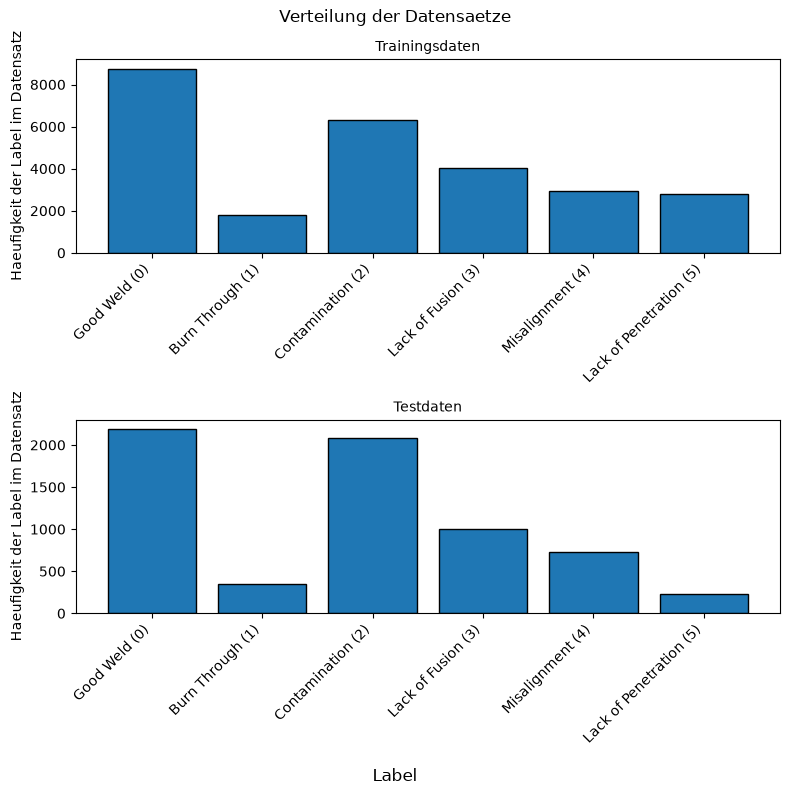

In [60]:
orig_set.plot_distribution()


In [61]:
for filename, label in orig_set.train_data.items():
    print(filename, label)

print(orig_set.train_dir)

170906-113317-Al 2mm-part3/frame_00647.png 1
170906-113317-Al 2mm-part3/frame_00672.png 1
170906-113317-Al 2mm-part3/frame_00677.png 1
170906-113317-Al 2mm-part3/frame_00646.png 1
170906-113317-Al 2mm-part3/frame_00691.png 1
170906-113317-Al 2mm-part3/frame_00684.png 1
170906-113317-Al 2mm-part3/frame_00665.png 1
170906-113317-Al 2mm-part3/frame_00668.png 1
170906-113317-Al 2mm-part3/frame_00651.png 1
170906-113317-Al 2mm-part3/frame_00655.png 1
170906-113317-Al 2mm-part3/frame_00657.png 1
170906-113317-Al 2mm-part3/frame_00687.png 1
170906-113317-Al 2mm-part3/frame_00654.png 1
170906-113317-Al 2mm-part3/frame_00676.png 1
170906-113317-Al 2mm-part3/frame_00688.png 1
170906-113317-Al 2mm-part3/frame_00674.png 1
170906-113317-Al 2mm-part3/frame_00649.png 1
170906-113317-Al 2mm-part3/frame_00693.png 1
170906-113317-Al 2mm-part3/frame_00643.png 1
170906-113317-Al 2mm-part3/frame_00662.png 1
170906-113317-Al 2mm-part3/frame_00681.png 1
170906-113317-Al 2mm-part3/frame_00660.png 1
170906-113


170904-155523-Al 2mm/frame_01522.png 4
170904-155523-Al 2mm/frame_01613.png 4
170904-155523-Al 2mm/frame_01385.png 4
170904-155523-Al 2mm/frame_01568.png 4
170904-155523-Al 2mm/frame_01281.png 4
170904-155523-Al 2mm/frame_01437.png 4
170904-155523-Al 2mm/frame_01434.png 4
170904-155523-Al 2mm/frame_01680.png 4
170904-155523-Al 2mm/frame_01464.png 4
170904-155523-Al 2mm/frame_01469.png 4
170904-155523-Al 2mm/frame_01520.png 4
170904-155523-Al 2mm/frame_01370.png 4
170904-155523-Al 2mm/frame_01317.png 4
170904-155523-Al 2mm/frame_01319.png 4
170904-155523-Al 2mm/frame_01713.png 4
170904-155523-Al 2mm/frame_01283.png 4
170904-155523-Al 2mm/frame_01648.png 4
170904-155523-Al 2mm/frame_01298.png 4
170904-155523-Al 2mm/frame_01665.png 4
170904-155523-Al 2mm/frame_01511.png 4
170904-155523-Al 2mm/frame_01492.png 4
170904-155523-Al 2mm/frame_01565.png 4
170904-155523-Al 2mm/frame_01597.png 4
170904-155523-Al 2mm/frame_01332.png 4
170904-155523-Al 2mm/frame_01562.png 4
170904-155523-Al 2mm/fra

  170913-152931-Al 2mm-part1/frame_00494.png (Label: 0) - Size: (800, 974)
  170906-113317-Al 2mm-part3/frame_00647.png (Label: 1) - Size: (800, 974)
  170904-141730-Al 2mm-part2/frame_00145.png (Label: 2) - Size: (800, 974)
  170906-150010-Al 2mm/frame_00494.png (Label: 3) - Size: (800, 974)
  170904-145718-Al 2mm-part2/frame_00647.png (Label: 4) - Size: (800, 974)
  170905-110711-Al 2mm-part1/frame_00280.png (Label: 5) - Size: (800, 974)


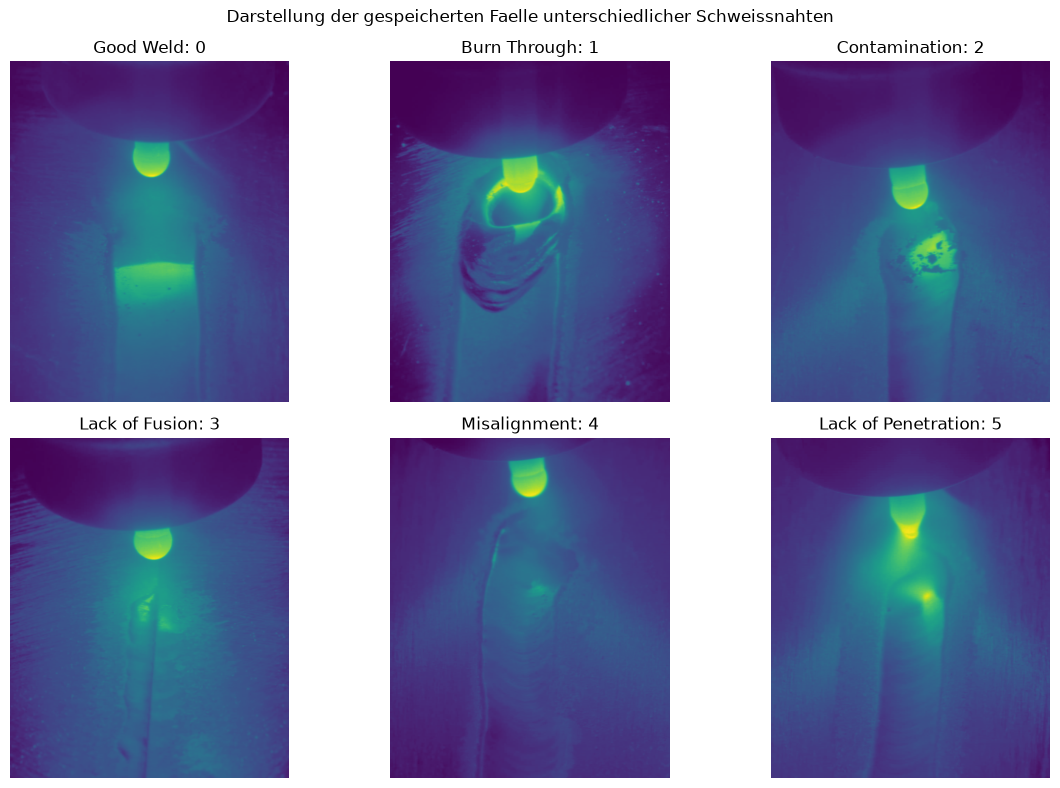

===Groesse der ersten 10 Bilder im Trainings-Datensatz===
    170906-113317-Al 2mm-part3/frame_00647.png: (800, 974)
    170906-113317-Al 2mm-part3/frame_00672.png: (800, 974)
    170906-113317-Al 2mm-part3/frame_00677.png: (800, 974)
    170906-113317-Al 2mm-part3/frame_00646.png: (800, 974)
    170906-113317-Al 2mm-part3/frame_00691.png: (800, 974)
    170906-113317-Al 2mm-part3/frame_00684.png: (800, 974)
    170906-113317-Al 2mm-part3/frame_00665.png: (800, 974)
    170906-113317-Al 2mm-part3/frame_00668.png: (800, 974)
    170906-113317-Al 2mm-part3/frame_00651.png: (800, 974)
    170906-113317-Al 2mm-part3/frame_00655.png: (800, 974)


In [62]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Darstellung der gespeicherten Faelle unterschiedlicher Schweissnahten')

#images_by_label = defaultdict(list)

lab_meaning = ['Good Weld', 'Burn Through', 'Contamination', 'Lack of Fusion', 'Misalignment', 'Lack of Penetration']
keys = [0, 1, 2, 3, 4, 5]
images_by_label = {key: [] for key in keys}
plot_idx = 0

for image_name, label in orig_set.train_data.items():
    # Namen der Bilder werden aneinander an eine Liste unter dem Label angehaengt
    images_by_label[label].append(image_name)

for label in sorted(images_by_label.keys()):
    # Zugriff auf das erste Namenselement aus images_by_label, je nach dem aktuellen key bzw. label
    image_name = images_by_label[label][0]
    # orig_set.train_dir enthaelt den uebergeordneten Dateipfad, der das Bild speichert
    image_path = orig_set.train_dir / image_name
    label_description = lab_meaning[plot_idx]
    img = Image.open(image_path)
    # Integer Division, so dass ab 3 eine 1 als Ergebnis resultiert, vorher 0
    row = plot_idx // 3
    # Modulo Operation, um fuer 0,3 = 0; 1,4 = 1; 2,5 = 2
    col = plot_idx % 3
    axes[row, col].imshow(img)
    axes[row, col].set_title(f'{label_description}: {label}')
    axes[row, col].axis('off')
    plot_idx += 1

    print(f"  {image_name} (Label: {label}) - Size: {img.size}")
plt.tight_layout()
plt.show()

orig_set.image_size_info("train")

In [63]:
target_folder = r"C:\Users\domin\Desktop\al5083_subset_balanced_2400"
subset = orig_set.create_balanced_subset(
    output_dir=target_folder,
    samples_per_label=400,
    seed=42,
    copy_files=True,
    split='train'
)
# 2. Test-Subset erstellen (z.B. 100 Bilder pro Klasse)
print("\n--- Generiere Test-Subset ---")
test_subset = orig_set.create_balanced_subset(
    output_dir=target_folder,
    split="test",
    samples_per_label=None  # Wichtig: weniger als 234 wählen!
)

Bilder kopiert: 2400 nach: C:\Users\domin\Desktop\al5083_subset_balanced_2400\train
Subset-JSON gespeichert: C:\Users\domin\Desktop\al5083_subset_balanced_2400\train\train.json
Gesamtzahl im Subset: 2400


,label,Vorhandene Bilder,Gewaehlte Bilder
0,0,8758,400
1,1,1783,400
2,2,6325,400
3,3,4028,400
4,4,2953,400
5,5,2819,400



--- Generiere Test-Subset ---
Bilder kopiert: 6588 nach: C:\Users\domin\Desktop\al5083_subset_balanced_2400\test
Subset-JSON gespeichert: C:\Users\domin\Desktop\al5083_subset_balanced_2400\test\test.json
Gesamtzahl im Subset: 6588


,label,Vorhandene Bilder,Gewaehlte Bilder
0,0,2189,2189
1,1,351,351
2,2,2078,2078
3,3,1007,1007
4,4,729,729
5,5,234,234


In [64]:
print(orig_set.train_class_counts)

Counter({0: 8758, 2: 6325, 3: 4028, 4: 2953, 5: 2819, 1: 1783})


In [65]:
data_dir_1 = Path("C:\\Users\\domin\\Desktop\\al5083_subset_balanced_2400")
trunc_set = DatasetManager(data_dir_1)
trunc_set.load_all()


===Trainings- und Testset (Inhalt)===

Geladene Bilddaten in C:\Users\domin\Desktop\al5083_subset_balanced_2400\train\train.json: 2400
Klassenverteilung in C:\Users\domin\Desktop\al5083_subset_balanced_2400\train\train.json: [(0, 400), (1, 400), (2, 400), (3, 400), (4, 400), (5, 400)]



Geladene Bilddaten in C:\Users\domin\Desktop\al5083_subset_balanced_2400\test\test.json: 6588
Klassenverteilung in C:\Users\domin\Desktop\al5083_subset_balanced_2400\test\test.json: [(0, 2189), (1, 351), (2, 2078), (3, 1007), (4, 729), (5, 234)]

===Bilddateien pro Split===
Gefundene Formate in train: {'json': 1, 'png': 2400}
Train Bilder: 2400
Gefundene Formate in test: {'json': 1, 'png': 6588}
Test Bilder: 6588


({'170906-144958-Al 2mm/frame_01345.png': 1,
  '170906-144958-Al 2mm/frame_00135.png': 1,
  '170906-113317-Al 2mm-part3/frame_00680.png': 1,
  '170906-144958-Al 2mm/frame_00884.png': 1,
  '170906-144958-Al 2mm/frame_01364.png': 1,
  '170906-144958-Al 2mm/frame_00714.png': 1,
  '170906-144958-Al 2mm/frame_00258.png': 1,
  '170906-144958-Al 2mm/frame_00510.png': 1,
  '170906-144958-Al 2mm/frame_01396.png': 1,
  '170906-144958-Al 2mm/frame_01407.png': 1,
  '170906-144958-Al 2mm/frame_01320.png': 1,
  '170906-144958-Al 2mm/frame_00551.png': 1,
  '170906-144958-Al 2mm/frame_01416.png': 1,
  '170906-144958-Al 2mm/frame_00329.png': 1,
  '170906-144958-Al 2mm/frame_00255.png': 1,
  '170906-144958-Al 2mm/frame_01387.png': 1,
  '170906-144958-Al 2mm/frame_01150.png': 1,
  '170906-144958-Al 2mm/frame_01117.png': 1,
  '170906-144958-Al 2mm/frame_00547.png': 1,
  '170906-144958-Al 2mm/frame_01003.png': 1,
  '170906-144958-Al 2mm/frame_01480.png': 1,
  '170906-144958-Al 2mm/frame_01926.png': 1,
  '1